# Imports

In [198]:
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np

import plotly.graph_objs as go

from sklearn.preprocessing import StandardScaler
from scipy import stats

# Env

In [10]:
load_dotenv()

True

In [11]:
wb_commodities_data_file_url = os.getenv('WB_COMMODITIES_DATA_FILE_URL')

In [12]:
wb_commodities_data_file_url

'https://thedocs.worldbank.org/en/doc/5d903e848db1d1b83e0ec8f744e55570-0350012021/related/CMO-Historical-Data-Monthly.xlsx'

In [13]:
wb_commodities_data_local_filepath = os.getenv('WB_COMMODITIES_DATA_LOCAL_FILEPATH')

In [14]:
wb_commodities_data_local_filepath

'/Users/zayankhan/Desktop/1212 Analytics/Cotton Data/World Bank/CMO-Historical-Data-Monthly.xlsx'

# Functions

In [48]:
def find_cols(df, word):
    """
    Find columns in a DataFrame that contain a specific word.

    Parameters:
        df (DataFrame): The DataFrame to search.
        word (str): The word to search for in column names.

    Returns:
        list: A list of column names containing the specified word.
    """
    return [col for col in df.columns if word in col]

In [132]:
# Define a function to remove outliers from a column
def remove_outliers(df):
    z_scores = np.abs(stats.zscore(df))
    threshold = 3
    return df[(z_scores < threshold)]

In [232]:
# Define a function to get outliers from a column
def get_outliers(df):
    z_scores = np.abs(stats.zscore(df))
    threshold = 3
    return df[(z_scores > threshold)]

# Load

In [19]:
wb_commodities_df = pd.read_excel(wb_commodities_data_local_filepath, sheet_name=1, skiprows=4)

In [20]:
wb_commodities_df

,Unnamed: 0,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African **","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
0,NaN,($/bbl),($/bbl),($/bbl),($/bbl),($/mt),($/mt),($/mmbtu),($/mmbtu),($/mmbtu),...,($/mt),($/dmtu),($/mt),($/mt),($/mt),($/mt),($/mt),($/troy oz),($/troy oz),($/troy oz)
1,1960M01,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,715.4,206.1,2180.4,1631,260.8,35.27,83.5,0.9137
2,1960M02,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,728.19,203.7,2180.4,1631,244.9,35.27,83.5,0.9137
3,1960M03,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,684.94,210.3,2173.8,1631,248.7,35.27,83.5,0.9137
4,1960M04,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,723.11,213.6,2178.2,1631,254.6,35.27,83.5,0.9137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,2023M11,81.354333,83.183,83.45,77.43,126.82,109,2.7084,14.485055,12.723407,...,2202.26,131.07,8189.59,2188.46,24167.86,17027.36,2543.61,1984.11,905.75,23.488
768,2023M12,75.719333,77.858,77.22,72.08,141.82,108.8294,2.5265,11.506658,14.439545,...,2182.43,137.05,8399.94,2026.91,24600.26,16460.84,2502.39,2026.18,935.47,23.878
769,2024M01,77.672333,80.227,78.86,73.93,124.9,106.75,3.1806,9.559614,14.344154,...,2192.82,135.82,8338.88,2086.12,25099.84,16103.83,2515.42,2034.04,925.86,22.916
770,2024M02,80.548,83.764,81.18,76.7,124.22,105.193,1.7211,8.148381,13.644993,...,2179.46,124.39,8304.95,2079.83,26104.1,16338.46,2360.09,2023.24,894.29,22.657


# Transform

### Update col names to include metrics and to numeric

In [22]:
new_header = wb_commodities_df.columns + wb_commodities_df.iloc[0]

In [25]:
wb_commodities_df.columns = new_header

In [27]:
wb_commodities_df = wb_commodities_df.drop(0)

In [72]:
wb_commodities_df = wb_commodities_df.apply(pd.to_numeric, errors='coerce')

### Set YearMonth index as datetime index

In [36]:
wb_commodities_df = wb_commodities_df.rename(columns={wb_commodities_df.columns[0]: 'YearMonth'})

In [38]:
# Convert 'date' column to datetime format
wb_commodities_df['YearMonth'] = pd.to_datetime(wb_commodities_df['YearMonth'], format='%YM%m')

In [40]:
wb_commodities_df.set_index(wb_commodities_df['YearMonth'], inplace=True)

In [42]:
wb_commodities_df.drop('YearMonth', axis=1, inplace=True)

In [ ]:
wb_commodities_df = wb_commodities_df.apply(pd.to_numeric, errors='coerce')

### Find cols

In [50]:
find_cols(wb_commodities_df, 'Cotton')

['Cotton, A Index($/kg)']

# Corellations

In [173]:
scaler = StandardScaler()

## w/Outliers 

In [174]:
# Scale the data
wb_commodities_data_scaled = scaler.fit_transform(wb_commodities_df)

In [183]:
# Convert scaled_data back to DataFrame
wb_commodities_df_scaled = pd.DataFrame(wb_commodities_data_scaled, columns=wb_commodities_df.columns, index=wb_commodities_df.index)

In [176]:
# Calculate correlations
wb_commodities_correlation_matrix = wb_commodities_df_scaled.corr()

In [177]:
wb_commodities_correlation_matrix['Cotton, A Index($/kg)'].sort_values(ascending=False)

Cotton, A Index($/kg)          1.000000
Palm kernel oil($/mt)          0.796751
Palm oil($/mt)                 0.783710
Coffee, Arabica($/kg)          0.783563
Maize($/mt)                    0.775892
                                 ...   
Fish meal($/mt)                0.425819
Natural gas, US($/mmbtu)       0.383763
Banana, Europe($/kg)           0.334587
Natural gas index(2010=100)    0.321347
Plywood(cents/sheet)           0.133395
Name: Cotton, A Index($/kg), Length: 71, dtype: float64

<AxesSubplot:xlabel='YearMonth'>

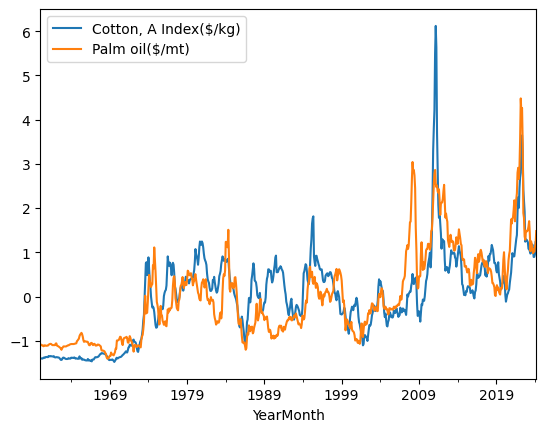

In [184]:
wb_commodities_df_scaled[['Cotton, A Index($/kg)', 'Palm oil($/mt)']].plot()

## w/o Outliers

In [160]:
wb_commodities_outliers_rm_df = remove_outliers(wb_commodities_df)

In [180]:
# Scale the data
wb_commodities_outliers_rm_data_scaled = scaler.fit_transform(wb_commodities_outliers_rm_df)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:1047: RuntimeWarning: invalid value encountered in divide
  result
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:1052: RuntimeWarning: invalid value encountered in divide
  else:
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:1072: RuntimeWarning: invalid value encountered in divide
  Parameters


In [181]:
# Convert scaled_data back to DataFrame
wb_commodities_outliers_rm_df_scaled = pd.DataFrame(wb_commodities_outliers_rm_data_scaled, columns=wb_commodities_outliers_rm_df.columns, index=wb_commodities_outliers_rm_df.index)

In [187]:
# Calculate correlations
wb_commodities_outliers_rm_correlation_matrix = wb_commodities_outliers_rm_df_scaled.corr()

In [216]:
cotton_correlations = wb_commodities_outliers_rm_correlation_matrix['Cotton, A Index($/kg)'].sort_values(ascending=False)

In [221]:
cotton_top_correlations = list(cotton_correlations[:5].keys())
cotton_top_correlations

['Cotton, A Index($/kg)',
 'Coffee, Arabica($/kg)',
 'Soybeans($/mt)',
 'Sugar, US($/kg)',
 'Maize($/mt)']

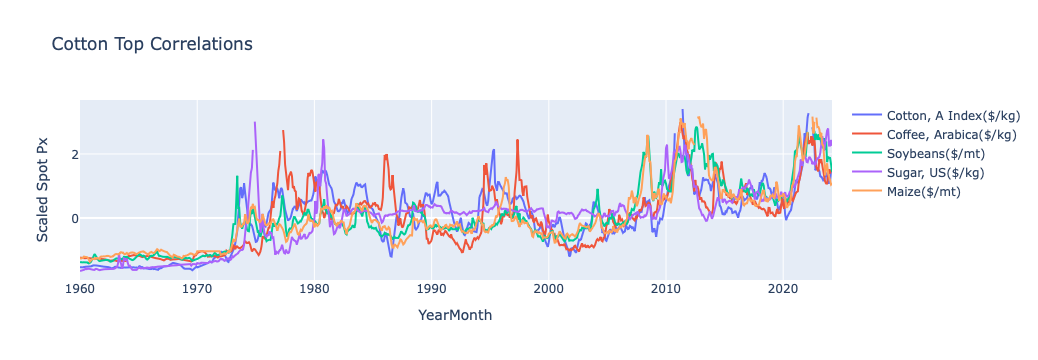

In [224]:
# Create traces for each commodity
traces = []
for commodity in cotton_top_correlations:
    trace = go.Scatter(x=wb_commodities_outliers_rm_df_scaled.index, y=wb_commodities_outliers_rm_df_scaled[commodity], mode='lines', name=commodity)
    traces.append(trace)

# Define layout for the plot
layout = go.Layout(
    title='Cotton Top Correlations',
    xaxis=dict(title='YearMonth'),
    yaxis=dict(title='Scaled Spot Px')
)

# Create figure and plot
fig = go.Figure(data=traces, layout=layout)

# Display the interactive plot
fig.show()


# Cotton DF

In [109]:
wb_cotton_df = wb_commodities_df[['Cotton, A Index($/kg)']].loc['1975-01-01':]

In [225]:
wb_cotton_outliers_rm_df = remove_outliers(wb_cotton_df)

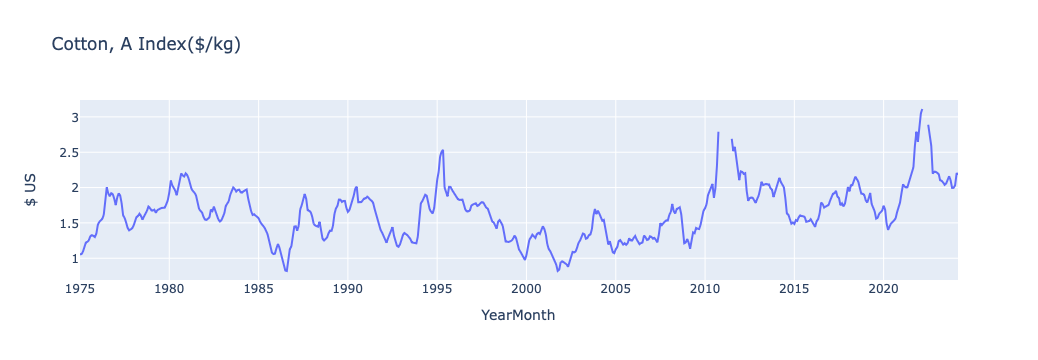

In [231]:
cotton_trace = go.Scatter(x=wb_cotton_outliers_rm_df.index, y=wb_cotton_outliers_rm_df['Cotton, A Index($/kg)'], mode='lines', name='Cotton, A Index($/kg)')
# Define layout for the plot
layout = go.Layout(
    title='Cotton, A Index($/kg)',
    xaxis=dict(title='YearMonth'),
    yaxis=dict(title='$ US')
)

# Create figure and plot
fig = go.Figure(data=cotton_trace, layout=layout)

# Display the interactive plot
fig.show()

In [238]:
wb_cotton_outliers_df = get_outliers(wb_cotton_df).dropna()

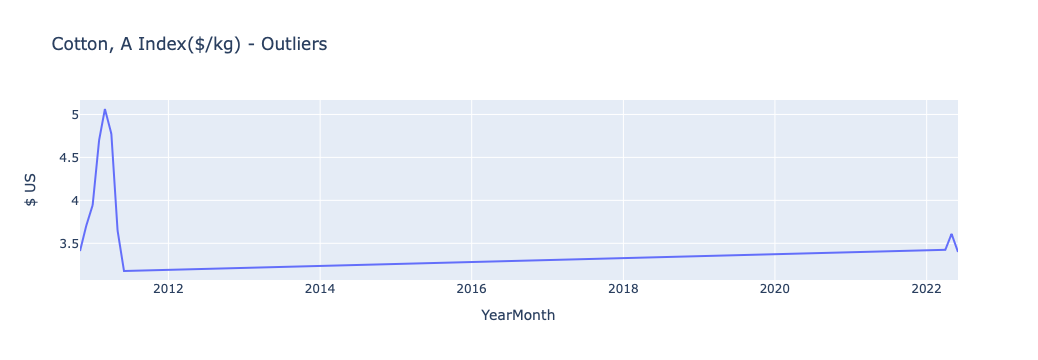

In [239]:
cotton_outliers_trace = go.Scatter(x=wb_cotton_outliers_df.index, y=wb_cotton_outliers_df['Cotton, A Index($/kg)'], mode='lines', name='Cotton, A Index($/kg)')
# Define layout for the plot
layout = go.Layout(
    title='Cotton, A Index($/kg) - Outliers',
    xaxis=dict(title='YearMonth'),
    yaxis=dict(title='$ US')
)

# Create figure and plot
fig = go.Figure(data=cotton_outliers_trace, layout=layout)

# Display the interactive plot
fig.show()